# Training

In [1]:
%matplotlib inline
from Trainer import Trainer
import torch
import torch.nn as nn

if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on GPU.


In [2]:
!nvidia-smi

Sat Jun  3 22:58:45 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.41.03              Driver Version: 530.41.03    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-PCIE-32GB            On | 00000000:58:00.0 Off |                    0 |
| N/A   32C    P0               36W / 250W|  16094MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [3]:
trainer = Trainer(data_path="/dtu/datasets1/02514/hotdog_nothotdog/",
                 image_size=128,
                 batch_size=64)

The code will run on GPU.


In [4]:
class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.convolutional = nn.Sequential(
                nn.Conv2d(3, 32, 7, stride=1, padding=3),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Conv2d(32, 32, 3, stride=1, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(2),
            
                nn.Conv2d(32, 64, 3, stride=1, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Conv2d(64, 64, 3, stride=1, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
            
                nn.Conv2d(64, 128, 3, stride=1, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(),
                nn.Conv2d(128, 128, 3, stride=1, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
        )

        self.fully_connected = nn.Sequential(
                nn.Linear(16*16*128, 1024),
                nn.ReLU(),
                nn.Linear(1024, 512),
                nn.ReLU(),
                nn.Linear(512, 1),
                nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.convolutional(x)
        #reshape x so it becomes flat, except for the first dimension (which is the minibatch)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        return x.view(-1)

In [5]:
model = Network().to(device)

#Initialize the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

out_dict = trainer.train(model, optimizer, num_epochs=10)


  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.687	 test: 0.693	 Accuracy train: 56.2%	 test: 48.1%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.656	 test: 0.643	 Accuracy train: 64.4%	 test: 65.8%


...

Loss train: 0.463	 test: 0.536	 Accuracy train: 79.5%	 test: 73.7%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.448	 test: 0.562	 Accuracy train: 79.6%	 test: 72.1%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.445	 test: 0.498	 Accuracy train: 79.0%	 test: 76.6%


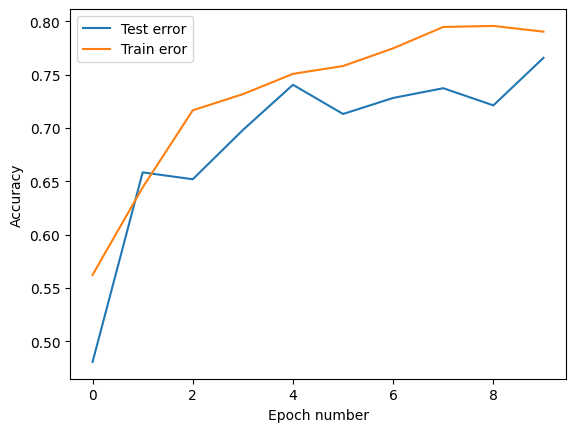

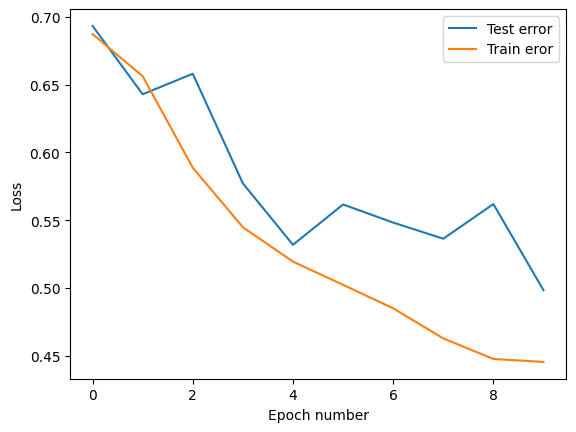

In [6]:
trainer.plot_acc_loss()

In [12]:
model = Network().to(device)

#Initialize the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

out_dict = trainer.train(model, optimizer, num_epochs=10)

  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.675	 test: 0.680	 Accuracy train: 58.4%	 test: 64.0%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.605	 test: 0.599	 Accuracy train: 69.0%	 test: 69.1%


...

Loss train: 0.370	 test: 0.485	 Accuracy train: 84.2%	 test: 77.2%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.341	 test: 0.479	 Accuracy train: 86.6%	 test: 77.2%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.318	 test: 0.477	 Accuracy train: 87.4%	 test: 77.7%
